In [32]:
from tinyphysics import TinyPhysicsModel, TinyPhysicsSimulator, CONTROL_START_IDX
from controllers import pid, zero, pid_v2, pid_ref, custom
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()


In [33]:
def plot_rollout(sim):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    
    # First subplot: Lateral Acceleration
    ax1.plot(sim.target_lataccel_history, label="Target Lateral Acceleration", alpha=0.5)
    ax1.plot(sim.current_lataccel_history, label="Actual Lateral Acceleration", alpha=0.5)
    ax1.legend()
    ax1.set_ylabel("Lateral Acceleration")
    ax1.set_title("Rollout: Lateral Acceleration")
    
    # Second subplot: Control Action
    print(sim.action_history[-5:])
    ax2.plot(sim.action_history, label="Control Action", alpha=0.5)
    ax2.legend()
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Control Action")
    ax2.set_title("Rollout: Control Action")
    
    plt.tight_layout()
    plt.show()

{'lataccel_cost': 1.011074220619, 'jerk_cost': 25.289471589926148, 'total_cost': 75.84318262087615}
[0.413125712725266, 0.4067090534424709, 0.4035309165670727, 0.3828456786753253, 0.37279402798151146]


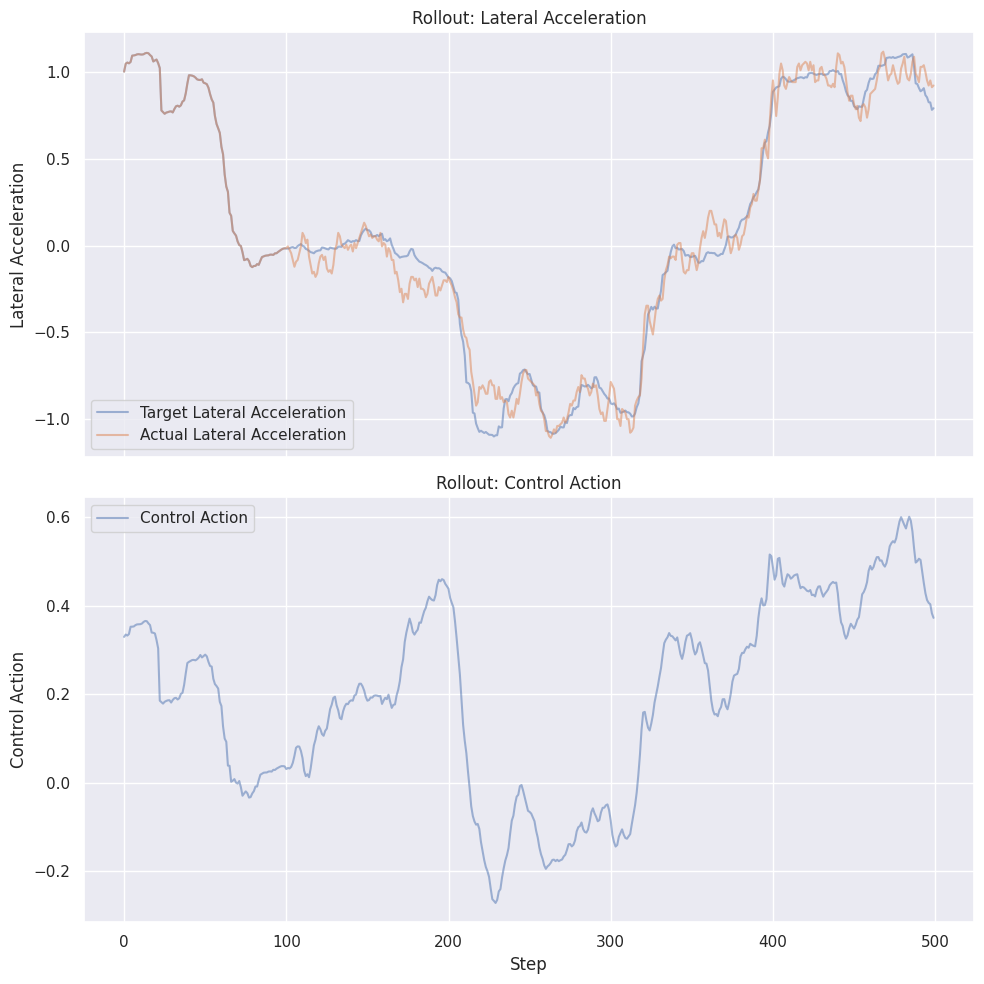

In [34]:
controller = pid_ref.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
print(sim.rollout())
plot_rollout(sim)

{'lataccel_cost': 0.9316435753044479, 'jerk_cost': 29.00865240234614, 'total_cost': 75.59083116756854}
[0.22480854956953925, 0.1969003848461739, 0.1801554860121547, 0.1969003848461739, 0.2136452836801931]


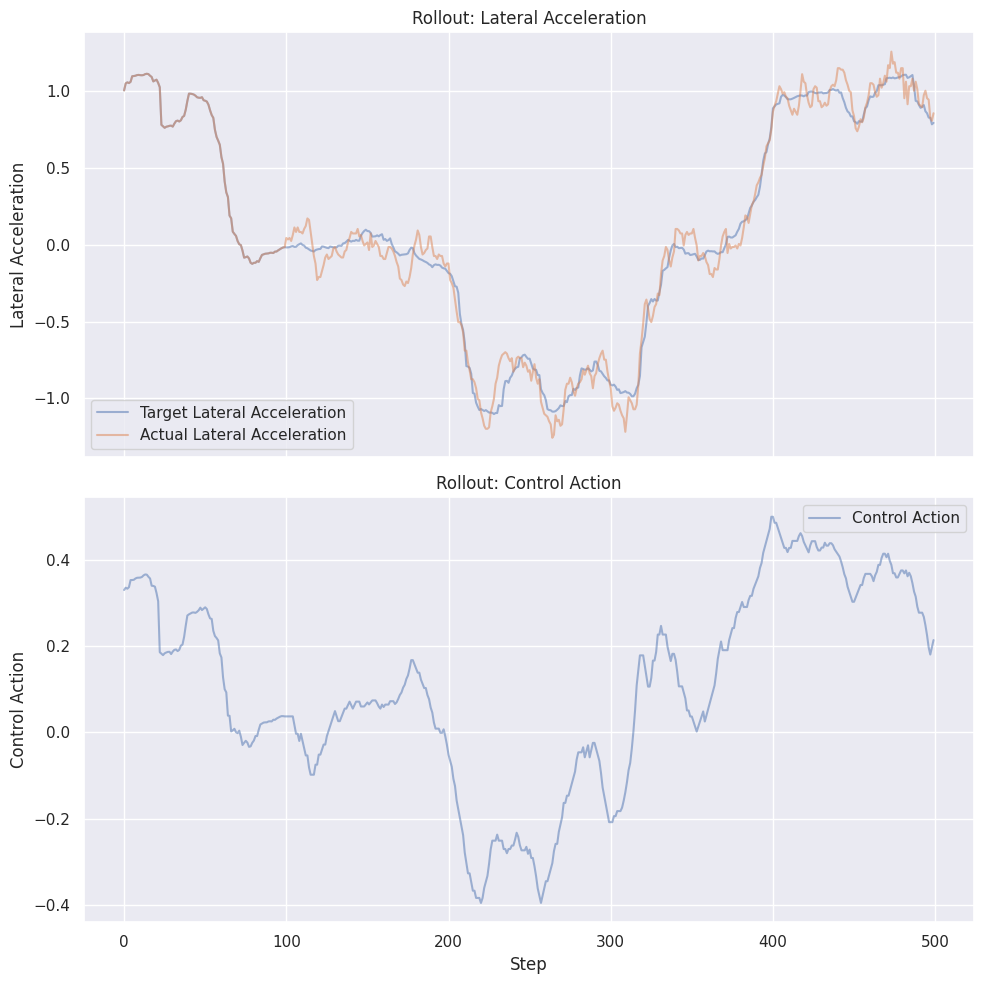

In [36]:
import importlib
importlib.reload(custom)
controller = custom.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
if getattr(controller, "giveSim", None):
  controller.giveSim(sim)
print(sim.rollout())
plot_rollout(sim)